# 05 - Regression Modeling

# Predicción de días de entrega mediante modelos de regresión

En esta etapa del proyecto se desarrolla un problema de regresión utilizando la variable `dias_entrega`. El objetivo es estimar cuántos días podría tardar un envío utilizando variables logísticas relacionadas con distancia, incidencias, carga y características del vehículo.

# Objetivos

- Construir un problema de regresión.
- Entrenar modelos de regresión.
- Comparar métricas.
- Seleccionar el mejor modelo.
- Complementar el análisis de clasificación realizado anteriormente.

In [1]:
%load_ext kedro.ipython

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 1. Carga del dataset

In [2]:
df = catalog.load("dataset_modelo")

df.head()


[05/10/26 19:24:22] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=5385098;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=5385099;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,...,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,...,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,...,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,...,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,...,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,...,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


# 2. Exploración de la variable objetivo

In [3]:
df["dias_entrega"].describe()



count    1030.000000
mean        7.041748
std         0.817213
min         4.000000
25%         7.000000
50%         7.000000
75%         7.000000
max        10.000000
Name: dias_entrega, dtype: float64

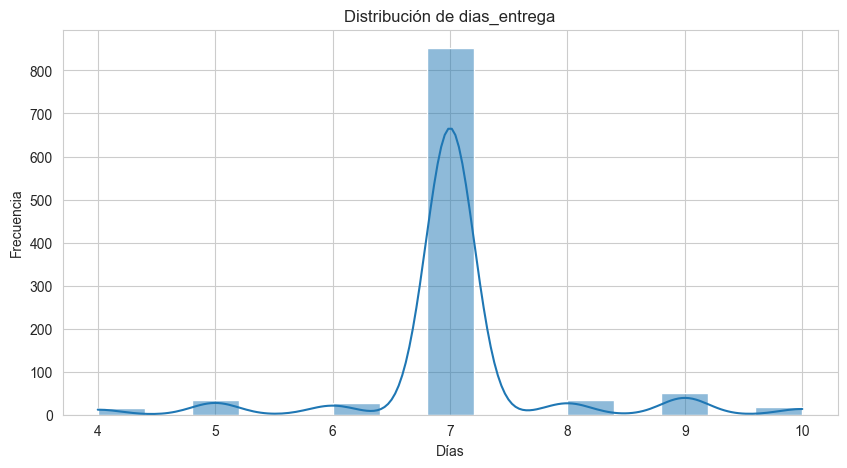

In [4]:
sns.histplot(df["dias_entrega"], bins=15, kde=True)

plt.title("Distribución de dias_entrega")
plt.xlabel("Días")
plt.ylabel("Frecuencia")

plt.show()


La variable `dias_entrega` presenta un rango relativamente controlado, principalmente entre 4 y 10 días. Esto permite trabajar un problema de regresión enfocado en pequeñas variaciones de tiempo.

# 3. Selección de variables

In [5]:
variables_modelo = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "velocidad_promedio_km_h",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo"
]

objetivo = "dias_entrega"

X = df[variables_modelo]
y = df[objetivo]

print(X.shape)
print(y.shape)


(1030, 14)
(1030,)


# 4. Preprocesamiento

In [6]:
variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])


# 5. División entrenamiento y prueba

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (824, 14)
X_test: (206, 14)


# 6. Función de evaluación

In [8]:
def evaluar_modelo_regresion(nombre_modelo, modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"===== {nombre_modelo} =====")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    comparacion = pd.DataFrame({
        "Real": y_test.values,
        "Predicción": y_pred
    })

    display(comparacion.head(10))

    plt.scatter(y_test, y_pred)

    plt.xlabel("Valores reales")
    plt.ylabel("Predicciones")

    plt.title(f"Real vs Predicción - {nombre_modelo}")

    plt.show()

    return {
        "modelo": nombre_modelo,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }


# 7. Linear Regression

===== Linear Regression =====
MAE  : 0.4439
RMSE : 0.8825
R²   : -0.0634


,Real,Predicción
0,7.0,6.733526
1,5.0,7.040122
2,7.0,7.152486
3,7.0,7.030860
4,7.0,7.094263
5,10.0,7.235348
6,9.0,7.175096
7,7.0,6.946878
8,7.0,7.062563
9,7.0,6.965117


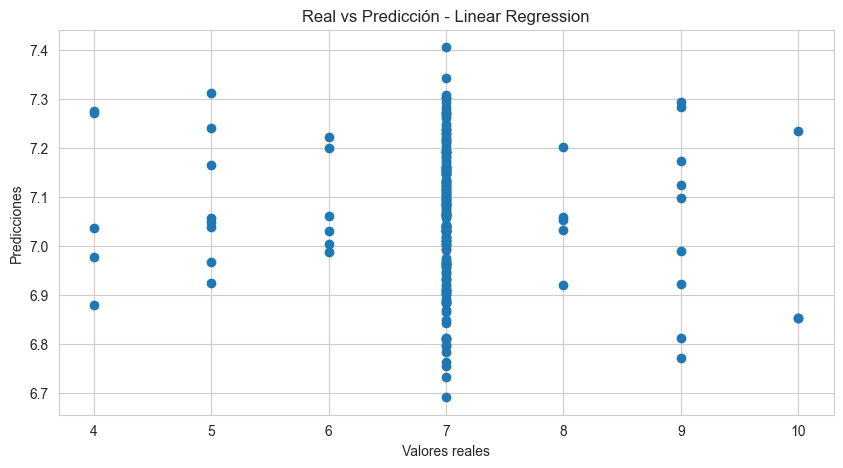

In [9]:
modelo_linear = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LinearRegression())
])

modelo_linear.fit(X_train, y_train)

resultado_linear = evaluar_modelo_regresion(
    "Linear Regression",
    modelo_linear,
    X_test,
    y_test
)


Linear Regression se utiliza como modelo base. Si el rendimiento resulta bajo, puede indicar que las relaciones presentes en el dataset no son completamente lineales.

# 8. Decision Tree Regressor

===== Decision Tree Regressor =====
MAE  : 0.5171
RMSE : 0.9129
R²   : -0.1379


,Real,Predicción
0,7.0,6.854545
1,5.0,7.022989
2,7.0,7.273810
3,7.0,6.870370
4,7.0,6.718750
5,10.0,7.273810
6,9.0,7.167785
7,7.0,6.718750
8,7.0,7.167785
9,7.0,6.718750


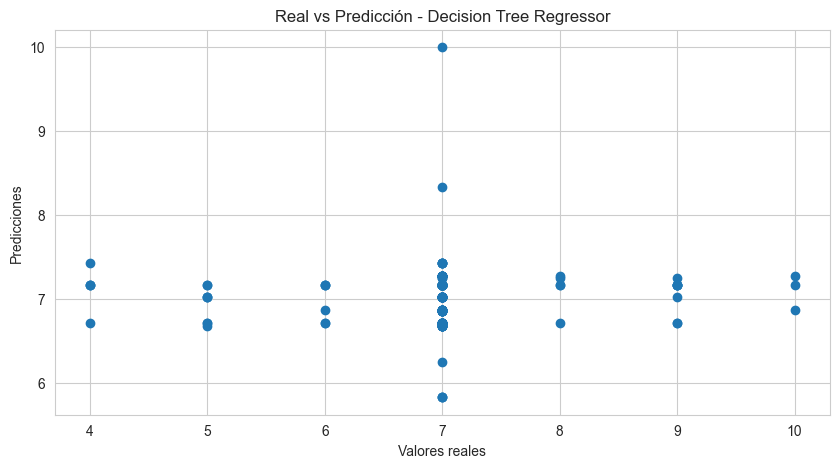

In [10]:
modelo_tree = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeRegressor(
        random_state=42,
        max_depth=5
    ))
])

modelo_tree.fit(X_train, y_train)

resultado_tree = evaluar_modelo_regresion(
    "Decision Tree Regressor",
    modelo_tree,
    X_test,
    y_test
)


Decision Tree Regressor permite capturar relaciones no lineales y patrones más complejos presentes en los datos logísticos.

# 9. Random Forest Regressor

===== Random Forest Regressor =====
MAE  : 0.4382
RMSE : 0.8671
R²   : -0.0267


,Real,Predicción
0,7.0,6.925051
1,5.0,6.981875
2,7.0,7.061614
3,7.0,7.131065
4,7.0,6.957265
5,10.0,7.257312
6,9.0,6.903675
7,7.0,6.918419
8,7.0,7.023782
9,7.0,6.946700


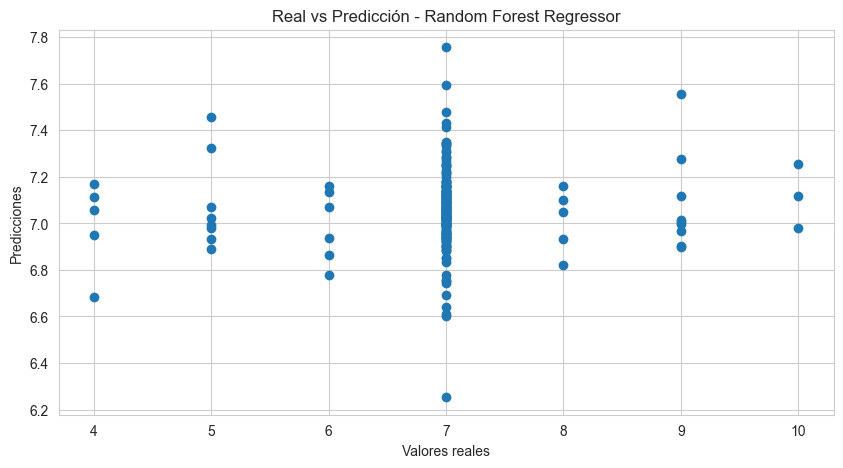

In [11]:
modelo_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=8
    ))
])

modelo_rf.fit(X_train, y_train)

resultado_rf = evaluar_modelo_regresion(
    "Random Forest Regressor",
    modelo_rf,
    X_test,
    y_test
)


Random Forest combina múltiples árboles de decisión, lo que generalmente mejora la estabilidad y reduce el sobreajuste.

# 10. Comparación de modelos

In [12]:
tabla_resultados = pd.DataFrame([
    resultado_linear,
    resultado_tree,
    resultado_rf
])

tabla_resultados.sort_values(by="rmse")


,modelo,mae,rmse,r2
2,Random Forest Regressor,0.438167,0.867148,-0.026659
0,Linear Regression,0.443940,0.882537,-0.063420
1,Decision Tree Regressor,0.517056,0.912902,-0.137858


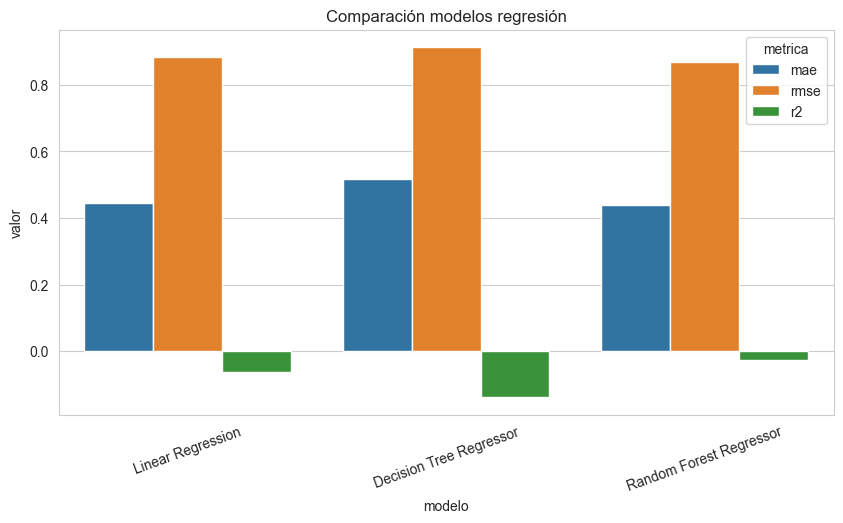

In [13]:
tabla_melt = tabla_resultados.melt(
    id_vars="modelo",
    value_vars=["mae", "rmse", "r2"],
    var_name="metrica",
    value_name="valor"
)

sns.barplot(
    data=tabla_melt,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación modelos regresión")
plt.xticks(rotation=20)

plt.show()


# 11. Selección del mejor modelo

In [14]:
mejor_modelo = tabla_resultados.sort_values(
    by="rmse",
    ascending=True
).iloc[0]

mejor_modelo



modelo    Random Forest Regressor
mae                      0.438167
rmse                     0.867148
r2                      -0.026659
Name: 2, dtype: object

# 12. Conclusiones

Este notebook permitió complementar el problema de clasificación trabajado anteriormente mediante un enfoque de regresión.

Mientras el modelo de clasificación buscaba determinar si una entrega sería tardía, el problema de regresión permitió estimar directamente cuántos días podría tardar un envío.

Los modelos basados en árboles permiten capturar relaciones más complejas entre distancia, incidencias, velocidad y tiempo de entrega.

Las métricas utilizadas permiten interpretar directamente el error promedio en días, lo que resulta útil desde el punto de vista logístico y operativo.